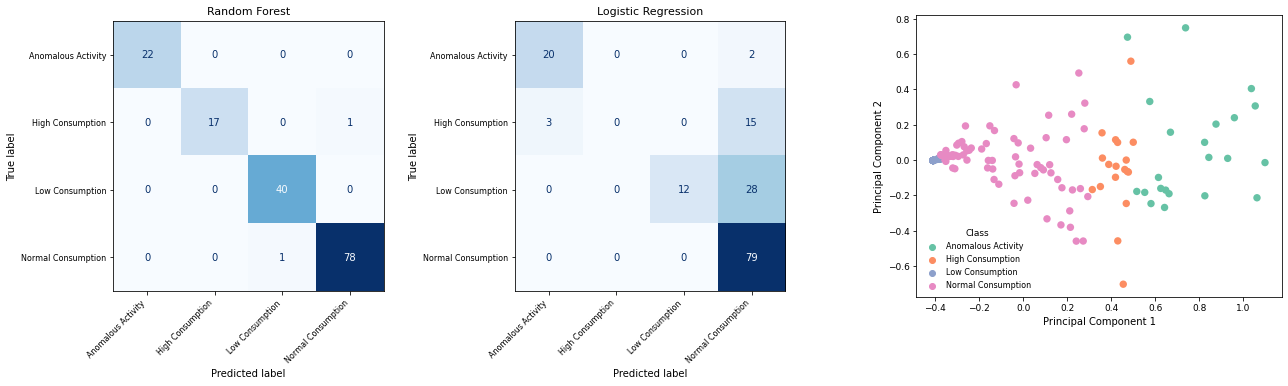

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler


# ============================================================
# 1. Detect the repository root
# ============================================================

current_dir = Path.cwd()

if (current_dir / "data").exists():
    repository_root = current_dir
elif (current_dir.parent / "data").exists():
    repository_root = current_dir.parent
else:
    raise FileNotFoundError(
        "The repository data directory could not be found. "
        "Run the notebook from the repository root or from "
        "the notebooks directory."
    )


# ============================================================
# 2. Load the dataset
# ============================================================

data_path = repository_root / "data" / "Dataset_Consumo_Label_v1.xlsx"

if not data_path.exists():
    raise FileNotFoundError(
        "Dataset not found. Place 'Dataset_Consumo_Label_v1.xlsx' "
        "inside the repository data directory."
    )

df = pd.read_excel(data_path)


# ============================================================
# 3. Validate the required columns
# ============================================================

feature_columns = [
    "Consumo",
    "Morning Shift",
    "Afternoon Shift",
    "Night Shift"
]

target_column = "Label"

required_columns = feature_columns + [target_column]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        "The dataset is missing the following required columns: "
        f"{missing_columns}"
    )


# ============================================================
# 4. Prepare features and labels
# ============================================================

df = df.dropna(subset=required_columns).copy()

X = df[feature_columns]
y = df[target_column]

class_order = [
    "Anomalous Activity",
    "High Consumption",
    "Low Consumption",
    "Normal Consumption"
]

unexpected_classes = sorted(set(y.unique()) - set(class_order))

if unexpected_classes:
    raise ValueError(
        "Unexpected class labels were found in the dataset: "
        f"{unexpected_classes}"
    )


# ============================================================
# 5. Configure stratified 10-fold cross-validation
# ============================================================

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)


# ============================================================
# 6. Define the supervised-learning pipelines
# ============================================================

random_forest_pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    (
        "classifier",
        RandomForestClassifier(
            random_state=42
        )
    )
])

logistic_regression_pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])


# ============================================================
# 7. Obtain cross-validated predictions
# ============================================================

random_forest_predictions = cross_val_predict(
    random_forest_pipeline,
    X,
    y,
    cv=cv
)

logistic_regression_predictions = cross_val_predict(
    logistic_regression_pipeline,
    X,
    y,
    cv=cv
)


# ============================================================
# 8. Calculate the confusion matrices
# ============================================================

random_forest_matrix = confusion_matrix(
    y,
    random_forest_predictions,
    labels=class_order
)

logistic_regression_matrix = confusion_matrix(
    y,
    logistic_regression_predictions,
    labels=class_order
)


# ============================================================
# 9. Calculate the PCA projection
# ============================================================

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "Principal Component 1": X_pca[:, 0],
    "Principal Component 2": X_pca[:, 1],
    "Class": y.to_numpy()
})


# ============================================================
# 10. Create Figure 9
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5.3),
    gridspec_kw={
        "width_ratios": [1, 1, 1.35]
    }
)


# ------------------------------------------------------------
# Panel 1: Random Forest confusion matrix
# ------------------------------------------------------------

random_forest_display = ConfusionMatrixDisplay(
    confusion_matrix=random_forest_matrix,
    display_labels=class_order
)

random_forest_display.plot(
    ax=axes[0],
    cmap="Blues",
    values_format="d",
    colorbar=False
)

axes[0].set_title(
    "Random Forest",
    fontsize=11
)

axes[0].set_xlabel(
    "Predicted label",
    fontsize=10
)

axes[0].set_ylabel(
    "True label",
    fontsize=10
)

axes[0].tick_params(
    axis="both",
    labelsize=8
)

axes[0].tick_params(
    axis="x",
    rotation=45
)

for label in axes[0].get_xticklabels():
    label.set_horizontalalignment("right")


# ------------------------------------------------------------
# Panel 2: Logistic Regression confusion matrix
# ------------------------------------------------------------

logistic_regression_display = ConfusionMatrixDisplay(
    confusion_matrix=logistic_regression_matrix,
    display_labels=class_order
)

logistic_regression_display.plot(
    ax=axes[1],
    cmap="Blues",
    values_format="d",
    colorbar=False
)

axes[1].set_title(
    "Logistic Regression",
    fontsize=11
)

axes[1].set_xlabel(
    "Predicted label",
    fontsize=10
)

axes[1].set_ylabel(
    "True label",
    fontsize=10
)

axes[1].tick_params(
    axis="both",
    labelsize=8
)

axes[1].tick_params(
    axis="x",
    rotation=45
)

for label in axes[1].get_xticklabels():
    label.set_horizontalalignment("right")


# ------------------------------------------------------------
# Panel 3: PCA projection
# ------------------------------------------------------------

sns.scatterplot(
    data=pca_df,
    x="Principal Component 1",
    y="Principal Component 2",
    hue="Class",
    hue_order=class_order,
    palette="Set2",
    s=55,
    edgecolor="none",
    ax=axes[2]
)

axes[2].set_xlabel(
    "Principal Component 1",
    fontsize=10
)

axes[2].set_ylabel(
    "Principal Component 2",
    fontsize=10
)

axes[2].tick_params(
    axis="both",
    labelsize=9
)

axes[2].legend(
    title="Class",
    loc="lower left",
    fontsize=8,
    title_fontsize=9,
    frameon=False
)

axes[2].grid(False)


# ============================================================
# 11. Final layout
# ============================================================

fig.tight_layout(
    w_pad=2.5
)

plt.show()